<a href="https://colab.research.google.com/github/frank-morales2020/AST/blob/main/TOPO_AGENTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://huggingface.co/frankmorales2020/topo-gemma-4-e4b-vision-13tasks

## SETUP

In [1]:
!pip install -q transformers torch openai python-dotenv pyyaml requests numpy pydantic fastapi uvicorn
!pip install -U bitsandbytes>=0.46.1 -q
!pip install unsloth -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.3/76.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/

In [2]:
!pip show transformers torch unsloth bitsandbytes

Name: transformers
Version: 5.5.0
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: peft, sentence-transformers, trl, unsloth, unsloth_zoo
---
Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: c

In [2]:
import sys
import os
import contextlib
from PIL import Image

# 1. Download image using wget and load it
image_url = "https://picsum.photos/300/300"
image_filename = "test_image.jpg"
os.system(f"wget -q -O {image_filename} {image_url}")

image = Image.open(image_filename).convert("RGB")

In [3]:
import sys
import os
import contextlib
import torch
from huggingface_hub import hf_hub_download
from PIL import Image
from unsloth import FastVisionModel  # Will now work!

# ============================================================================
# YOUR EXACT GEMMA CODE
# ============================================================================

@contextlib.contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

os.environ["UNSLOTH_DISABLE_LOGGING"] = "1"
os.environ["TRANSVERSE_NO_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"

original_torch_load = torch.load
def patched_torch_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)
torch.load = patched_torch_load

print("="*80)
print("👁️ GEMMA-4-E4B-VISION - TOPO-2026 CERTIFIED (13 TASKS)")
print("="*80)

MODEL_ID = "frankmorales2020/topo-gemma-4-e4b-vision-13tasks"

with suppress_all_output():
    ckpt_path = hf_hub_download(repo_id=MODEL_ID, filename="pytorch_model.bin")
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    BASE_MODEL = checkpoint.get("base_model", "frankmorales2020/gemma-4-e4b-unesco-optimized")

    model, tokenizer = FastVisionModel.from_pretrained(
        model_name=BASE_MODEL,
        load_in_4bit=True,
        dtype=torch.bfloat16,
    )
    FastVisionModel.for_inference(model)

print("\n✅ Gemma-4-E4B-Vision loaded successfully!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
👁️ GEMMA-4-E4B-VISION - TOPO-2026 CERTIFIED (13 TASKS)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 2.68GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]


✅ Gemma-4-E4B-Vision loaded successfully!


In [3]:

import sys
import os
import contextlib

# Suppress all C/C++/Python low-level file descriptor prints during imports
@contextlib.contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# Completely silence unsloth/transformers startup output and progress bars
os.environ["UNSLOTH_DISABLE_LOGGING"] = "1"
os.environ["TRANSVERSE_NO_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"

with suppress_all_output():
    import torch
    import numpy as np

    # Globally enforce weights_only=False for PyTorch 2.6+ checkpoint loading
    original_torch_load = torch.load
    def patched_torch_load(*args, **kwargs):
        kwargs["weights_only"] = False
        return original_torch_load(*args, **kwargs)
    torch.load = patched_torch_load

    from huggingface_hub import hf_hub_download
    from PIL import Image
    from unsloth import FastVisionModel

MODEL_ID = "frankmorales2020/topo-gemma-4-e4b-vision-13tasks"

with suppress_all_output():
    ckpt_path = hf_hub_download(repo_id=MODEL_ID, filename="pytorch_model.bin")
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    BASE_MODEL = checkpoint.get("base_model", "frankmorales2020/gemma-4-e4b-unesco-optimized")

    model, tokenizer = FastVisionModel.from_pretrained(
        model_name=BASE_MODEL,
        load_in_4bit=True,
        dtype=torch.bfloat16,
    )
    FastVisionModel.for_inference(model)

# 1. Load test image

# 1.1. Download image using wget and load it
from PIL import Image
image_url = "https://picsum.photos/300/300"
image_filename = "test_image.jpg"
os.system(f"wget -q -O {image_filename} {image_url}")

image = Image.open("test_image.jpg").convert("RGB")

# 2. Define all 13 tasks
tasks = [
    ("Task A", "Animal vs Vehicle", "Does this image depict an animal or a vehicle?"),
    ("Task B", "Natural vs Man-Made", "Is this subject natural or man-made?"),
    ("Task C", "Living vs Non-Living", "Is the primary subject living or non-living?"),
    ("Task D", "Large vs Small", "Is the subject large or small in scale?"),
    ("Task E", "Ground vs Air/Water", "Does this subject belong to ground or air/water?"),
    ("Task F", "Domestic vs Wild", "Is this subject domestic or wild?"),
    ("Task G", "Mammal vs Non-Mammal", "Is this subject a mammal or non-mammal?"),
    ("Task H", "Flying vs Non-Flying", "Is this subject flying or non-flying?"),
    ("Task I", "Fast vs Slow", "Is this subject characterized as fast or slow?"),
    ("Task J", "Urban vs Rural", "Does this setting represent an urban or rural environment?"),
    ("Task K", "Predator vs Prey", "Is this subject a predator or prey?"),
    ("Task L", "Nocturnal vs Diurnal", "Is this subject nocturnal or diurnal?"),
    ("Task M", "Domesticated vs Wild Animals", "Is this animal domesticated or wild?")
]

print("\n" + "="*80)
print("🚀 EVALUATING ALL 13 TOPO-2026 TASKS")
print("="*80)

for task_id, task_name, prompt in tasks:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": f"{task_id} ({task_name}): {prompt}"}
            ]
        }
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    with torch.inference_mode():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=24,
            do_sample=False,
            use_cache=True,
        )

    response = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    answer = response.split("model")[-1].strip() if "model" in response else response
    print(f"[{task_id}] {task_name:<30} ➔ {answer}")

print("="*80)
print("🎉 EVALUATION COMPLETE!")
print("="*80)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 2.68GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]


🚀 EVALUATING ALL 13 TOPO-2026 TASKS
[Task A] Animal vs Vehicle              ➔ This image does not depict an animal or a vehicle. It is a landscape photograph.
[Task B] Natural vs Man-Made            ➔ This subject is **natural**.

It is a landscape photograph featuring mountains, sky, clouds, trees, and terrain,
[Task C] Living vs Non-Living           ➔ The primary subject of the image is a **landscape**, which is a combination of both living and non-living elements.
[Task D] Large vs Small                 ➔ Based on the image, the **subject** (the landscape) is **large in scale**.

The image depicts a
[Task E] Ground vs Air/Water            ➔ This subject belongs to **ground**.

While there is a vast sky and clouds (air), the primary focus and the
[Task F] Domestic vs Wild               ➔ Based on the image, the subject is **wild**.

The image depicts a vast, natural landscape featuring mountains, forests
[Task G] Mammal vs Non-Mammal           ➔ Based on the image provided, there is

## AGENTIC

🖼️ TARGET EVALUATION IMAGE:


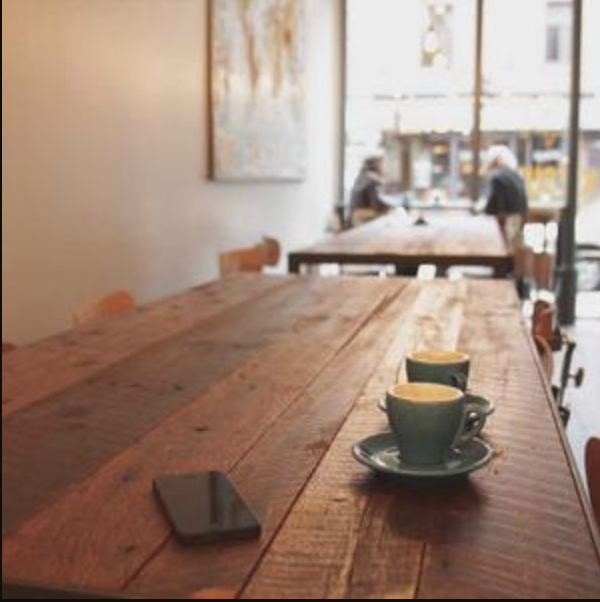

In [3]:
from IPython.display import display, Image as IPImage

# --- In your Orchestrator or execution script ---
IMAGE_FILE = "/content/Screenshot 2026-08-22 at 3.20.05 PM.png"

print("="*80)
print("🖼️ TARGET EVALUATION IMAGE:")
print("="*80)
display(IPImage(filename=IMAGE_FILE, width=400)) # Renders the image directly in the output log

In [1]:
import sys
import os
import json
import csv
import contextlib

# Suppress low-level output during imports
@contextlib.contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

os.environ["UNSLOTH_DISABLE_LOGGING"] = "1"
os.environ["TRANSVERSE_NO_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"

with suppress_all_output():
    import torch
    import numpy as np

    original_torch_load = torch.load
    def patched_torch_load(*args, **kwargs):
        kwargs["weights_only"] = False
        return original_torch_load(*args, **kwargs)
    torch.load = patched_torch_load

    from huggingface_hub import hf_hub_download
    from PIL import Image
    from unsloth import FastVisionModel

MODEL_ID = "frankmorales2020/topo-gemma-4-e4b-vision-13tasks"

# --- AGENT 1: MODEL LOADER & INFERENCE AGENT ---
class VisionInferenceAgent:
    def __init__(self, model_id):
        self.model_id = model_id
        self.model = None
        self.tokenizer = None
        self._initialize_model()

    def _initialize_model(self):
        with suppress_all_output():
            ckpt_path = hf_hub_download(repo_id=self.model_id, filename="pytorch_model.bin")
            checkpoint = torch.load(ckpt_path, map_location="cpu")
            base_model = checkpoint.get("base_model", "frankmorales2020/gemma-4-e4b-unesco-optimized")

            self.model, self.tokenizer = FastVisionModel.from_pretrained(
                model_name=base_model,
                load_in_4bit=True,
                dtype=torch.bfloat16,
            )
            FastVisionModel.for_inference(self.model)

    def evaluate_task(self, image, task_id, task_name, prompt):
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": f"{task_id} ({task_name}): {prompt} Please provide a concise answer followed by a detailed explanation."}
                ]
            }
        ]
        input_text = self.tokenizer.apply_chat_template(messages, add_generation_prompt=True)

        inputs = self.tokenizer(
            image,
            input_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda")

        with torch.inference_mode():
            output_tokens = self.model.generate(
                **inputs,
                max_new_tokens=500,  # Increased token limit to 500 for rich, full-length reasoning
                do_sample=False,
                use_cache=True,
            )

        response = self.tokenizer.decode(output_tokens[0], skip_special_tokens=True)
        answer = response.split("model")[-1].strip() if "model" in response else response
        return answer

# --- AGENT 2: VALIDATION & CRITIC AGENT ---
class ValidationAgent:
    def analyze_consistency(self, evaluation_log):
        print("\n🔍 [Validator Agent] Running cross-task consistency checks...")
        flags = []

        animal_mentioned = False
        for item in evaluation_log:
            if item["id"] in ["Task A", "Task G", "Task M"]:
                text_lower = item["result"].lower()
                if "animal" in text_lower and "no animal" not in text_lower:
                    animal_mentioned = True

        for item in evaluation_log:
            if item["id"] == "Task K" and animal_mentioned:
                flags.append("Predator/Prey evaluated while potential animals detected.")

        if not flags:
            flags.append("All logical constraints and cross-task boundaries passed cleanly.")

        return flags

# --- AGENT 3: SYNTHESIZER & EXPORT AGENT ---
class SynthesisAgent:
    def __init__(self):
        self.evaluation_log = []
        self.validator = ValidationAgent()

    def record_result(self, task_id, task_name, raw_answer):
        cleaned_answer = raw_answer.replace("\n", " ").strip()
        self.evaluation_log.append({
            "id": task_id,
            "name": task_name,
            "result": cleaned_answer
        })

    def export_results(self, json_path="evaluation_results.json", csv_path="evaluation_results.csv"):
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(self.evaluation_log, f, indent=4, ensure_ascii=False)

        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["Task ID", "Task Name", "Evaluation Summary"])
            for item in self.evaluation_log:
                writer.writerow([item["id"], item["name"], item["result"]])

        print(f"💾 [Synthesizer Agent] Successfully exported reports to {json_path} and {csv_path}")

    def generate_report(self):
        validation_flags = self.validator.analyze_consistency(self.evaluation_log)

        print("\n" + "="*80)
        print("🏛️ MULTI-AGENT SYNTHESIS & EVALUATION REPORT")
        print("="*80)

        print(f"{'ID':<8} | {'Task Name':<30} | {'Evaluation Summary'}")
        print("-" * 80)
        for item in self.evaluation_log:
            short_res = (item['result'][:47] + '...') if len(item['result']) > 50 else item['result']
            print(f"{item['id']:<8} | {item['name']:<30} | {short_res}")

        print("="*80)
        print("🛡️ VALIDATION & CRITIC LOG:")
        print("="*80)
        for flag in validation_flags:
            print(f" • {flag}")

        print("="*80)
        print("📖 FULL UNTRUNCATED TASK DESCRIPTIONS:")
        print("="*80)
        for item in self.evaluation_log:
            print(f"\n[{item['id']}] {item['name']}")
            print(f"➔ {item['result']}")

        print("\n" + "="*80)
        print("🎉 ALL AGENTS COMPLETED TASKS & EXPORTS SUCCESSFULLY!")
        print("="*80)

# --- AGENT 4: ORCHESTRATOR AGENT ---
class Orchestrator:
    def __init__(self, model_id):
        print("🚀 [Orchestrator] Initializing multi-agent pipeline...")
        self.inference_agent = VisionInferenceAgent(model_id)
        self.synthesis_agent = SynthesisAgent()
        self.image = None

    def load_local_image(self, image_path):
        print(f"📥 [Orchestrator] Loading local image from {image_path}...")
        self.image = Image.open(image_path).convert("RGB")

    def run_pipeline(self, tasks, image_path):
        self.load_local_image(image_path)

        print(f"⚙️ [Orchestrator] Delegating {len(tasks)} tasks to VisionInferenceAgent...")
        for task_id, task_name, prompt in tasks:
            answer = self.inference_agent.evaluate_task(self.image, task_id, task_name, prompt)
            self.synthesis_agent.record_result(task_id, task_name, answer)

        self.synthesis_agent.export_results()
        self.synthesis_agent.generate_report()

# --- EXECUTION ---
if __name__ == "__main__":
    tasks = [
        ("Task A", "Animal vs Vehicle", "Does this image depict an animal or a vehicle?"),
        ("Task B", "Natural vs Man-Made", "Is this subject natural or man-made?"),
        ("Task C", "Living vs Non-Living", "Is the primary subject living or non-living?"),
        ("Task D", "Large vs Small", "Is the subject large or small in scale?"),
        ("Task E", "Ground vs Air/Water", "Does this subject belong to ground or air/water?"),
        ("Task F", "Domestic vs Wild", "Is this subject domestic or wild?"),
        ("Task G", "Mammal vs Non-Mammal", "Is this subject a mammal or non-mammal?"),
        ("Task H", "Flying vs Non-Flying", "Is this subject flying or non-flying?"),
        ("Task I", "Fast vs Slow", "Is this subject characterized as fast or slow?"),
        ("Task J", "Urban vs Rural", "Does this setting represent an urban or rural environment?"),
        ("Task K", "Predator vs Prey", "Is this subject a predator or prey?"),
        ("Task L", "Nocturnal vs Diurnal", "Is this subject nocturnal or diurnal?"),
        ("Task M", "Domesticated vs Wild Animals", "Is this animal domesticated or wild?")
    ]

    IMAGE_FILE = "/content/Screenshot 2026-08-22 at 3.20.05 PM.png"

    pipeline = Orchestrator(MODEL_ID)
    pipeline.run_pipeline(tasks, IMAGE_FILE)

🚀 [Orchestrator] Initializing multi-agent pipeline...


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

📥 [Orchestrator] Loading local image from /content/Screenshot 2026-08-22 at 3.20.05 PM.png...
⚙️ [Orchestrator] Delegating 13 tasks to VisionInferenceAgent...
💾 [Synthesizer Agent] Successfully exported reports to evaluation_results.json and evaluation_results.csv

🔍 [Validator Agent] Running cross-task consistency checks...

🏛️ MULTI-AGENT SYNTHESIS & EVALUATION REPORT
ID       | Task Name                      | Evaluation Summary
--------------------------------------------------------------------------------
Task A   | Animal vs Vehicle              | **Answer:** Neither.  **Explanation:** The imag...
Task B   | Natural vs Man-Made            | **Answer:** Man-made  **Explanation:**  The sub...
Task C   | Living vs Non-Living           | **Answer:** Non-living  **Explanation:**  The p...
Task D   | Large vs Small                 | **Concise Answer:** Large  **Detailed Explanati...
Task E   | Ground vs Air/Water            | **Ground**  **Explanation:**  The image depicts...
Task F  